# Problém majáku (The Lighthouse Problem): Rekonstrukce polohy a 2D kontury věrohodnosti

Tento notebook řeší klasický statistický a fyzikální problém známý jako **The Lighthouse Problem** (původně formulovaný S. F. Gullem v roce 1988). Demonstrace je zaměřena na metodu maximální věrohodnosti (Maximum Likelihood Estimation, MLE), konstrukci jednorozměrných řezů věrohodnosti (podmíněných chyb) a dvourozměrných vrstevnic (kontur) sdružené věrohodnosti podle Wilkova teorému v prostředí CERN ROOT a Pythonu.

---

## Co se snažíme vyřešit?
Představme si maják umístěný na moři v neznámé kolmé vzdálenosti $y_0$ od dokonale rovného pobřeží a na neznámé podélné pozici $x_0$ podél břehu. 
Maják se otáčí a v náhodných časových okamžicích vyšle krátký, vysoce intenzivní záblesk světla. Světlo je vyzařováno izotropně (do všech směrů se stejnou pravděpodobností).

Podél pobřeží (které ztotožníme s osou $x$) máme rozmístěnou řadu fotodetektorů. Kdykoliv záblesk zasáhne pevninu, detektory zaznamenají přesnou souřadnici dopadu $x_k$. Celkem máme k dispozici soubor $N = 20\,000$ takových detekovaných zásahů uložených v souboru `hits.root`.

**Naším cílem je:**
1. Pouze z naměřených souřadnic dopadu $x_k$ co nejpřesněji určit neznámou polohu majáku $(x_0, y_0)$.
2. Ukázat, proč běžný aritmetický průměr $\bar{x}$ u tohoto problému fatálně selhává a nelze jej použít.
3. Kvantifikovat statistické nejistoty parametrů pomocí 1D řezů věrohodnosti (podmíněná chyba, když jeden parametr známe) a 2D vrstevnic (sdružená chyba, když jsou oba parametry neznámé).
4. Vykreslit výsledky nejprve v interaktivním **CERN ROOTu** (`%jsroot on`) a poté v publikační kvalitě v **Matplotlibu**.

### Přehled postupu krok za krokem:
1. **Fyzikální odvození:** Transformací rovnoměrného úhlového rozdělení odvodíme Cauchyho-Lorentzovo rozdělení pro souřadnice dopadu $x$.
2. **Průzkumová analýza:** Načteme data, spočítáme základní statistiky a ukážeme propastný rozdíl mezi průměrem a mediánem.
3. **Maximum Likelihood Fit:** Zformulujeme zápornou logaritmickou věrohodnost (NLL) a numericky nalezneme bod $(\hat{x}, \hat{y})$.
4. **1D podmíněné řezy:** Prozkoumáme chování věrohodnosti podél osy $x$ při fixním $y$ a podél osy $y$ při fixním $x$ a určíme $1\sigma$ interval podle pravidla $\Delta(-2\ln L) = 1.0$.
5. **2D sdružené kontury:** Vypočteme 2D mřížku věrohodnosti a vykreslíme izolinie pro hladiny spolehlivosti $1\sigma$ ($68.3\%$), $2\sigma$ ($95.4\%$) a $3\sigma$ ($99.7\%$) podle Wilkova teorému pro 2 stupně volnosti.
6. **Srovnání nejistot:** Porovnáme podmíněnou chybu s marginální (profilovou) chybou a zhodnotíme korelaci parametrů.

## 2. Fyzikální a matematický základ (Cauchyho rozdělení)

### Odvození hustoty pravděpodobnosti
Nechť maják leží na souřadnicích $(x_0, y_0)$, kde $y_0 > 0$ představuje vzdálenost majáku od břehu a $x_0$ je kolmý průmět majáku na pobřežní linii.
Úhel vyzařování záblesku $\theta$ měříme od kolmice k pobřeží. Protože maják vyzařuje rovnoměrně do všech směrů, úhel záblesků, které zasáhnou pobřeží, má rovnoměrné rozdělení pravděpodobnosti:
$$p(\theta) = \frac{1}{\pi}, \quad \theta \in \left(-\frac{\pi}{2}, \; \frac{\pi}{2}\right)$$

Záblesk vyslaný pod úhlem $\theta$ dopadne na pobřeží na souřadnici $x$:
$$x = x_0 + y_0 \tan \theta \implies \theta = \arctan\left(\frac{x - x_0}{y_0}\right)$$

Aplikujeme zákon transformace jednorozměrné hustoty pravděpodobnosti $p(x) \, |dx| = p(\theta) \, |d\theta|$:
$$\frac{d\theta}{dx} = \frac{1}{1 + \left(\frac{x - x_0}{y_0}\right)^2} \cdot \frac{1}{y_0} = \frac{y_0}{y_0^2 + (x - x_0)^2}$$

Odtud dostáváme výslednou hustotu pravděpodobnosti dopadu záblesku:
$$p(x \mid x_0, y_0) = \frac{1}{\pi} \frac{y_0}{y_0^2 + (x - x_0)^2}$$

V matematické statistice je toto rozdělení známo jako **Cauchyho rozdělení** (ve fyzice částic jako **Breit-Wignerovo rozdělení** či Lorentzova křivka):
* **$x_0$ (parametr polohy / location parameter):** udává polohu maxima a současně medián rozdělení.
* **$y_0$ (parametr měřítka / scale parameter):** představuje pološířku v polovičním maximu (HWHM, Half Width at Half Maximum).

---

### Proč výběrový průměr $\bar{x}$ fatálně selhává?
V naprosté většině fyzikálních úloh jsme zvyklí odhadovat střední hodnotu pomocí aritmetického průměru $\bar{x} = \frac{1}{N} \sum_{k=1}^N x_k$. Centrální limitní věta (CLT) nám říká, že pro rozdělení s konečným rozptylem $\sigma^2$ konverguje rozdělení průměru k normálnímu rozdělení s chybou $\sigma / \sqrt{N}$.

**U Cauchyho rozdělení však centrální limitní věta NEPLATÍ!**
1. **Neexistence momentů:** Integrál pro teoretickou střední hodnotu diverguje:
   $$\int_{-\infty}^{\infty} x \, \frac{y_0}{\pi(y_0^2 + (x - x_0)^2)} \, dx = \infty - \infty \quad (\text{neurčitý výraz})$$
   Rozptyl Cauchyho rozdělení je nekonečný: $\sigma^2 = \infty$.
2. **Rozdělení výběrového průměru:** Pomocí charakteristické funkce $\varphi(t) = \mathbb{E}[e^{itX}] = e^{it x_0 - y_0 |t|}$ lze snadno ukázat, že pro průměr $N$ nezávislých náhodných veličin s Cauchyho rozdělením platí:
   $$\varphi_{\bar{X}}(t) = \left[ \varphi\left(\frac{t}{N}\right) \right]^N = \left[ e^{i \frac{t}{N} x_0 - y_0 \frac{|t|}{N}} \right]^N = e^{it x_0 - y_0 |t|} = \varphi_X(t)$$
3. **Důsledek:** Výběrový průměr $\bar{x}$ má **úplně stejné Cauchyho rozdělení jako jediný naměřený bod**, a to pro libovolně velké $N$! Průměrováním $20\,000$ měření nezískáme vůbec žádné zpřesnění!

Proto je nutné použít **metodu maximální věrohodnosti (MLE)**, která asymptoticky dosahuje minimální možné disperze dané Cramérovou-Raovou mezí:
$$\mathrm{Var}(\hat{x}) \approx \frac{2 y_0^2}{N}, \qquad \mathrm{Var}(\hat{y}) \approx \frac{2 y_0^2}{N}$$
Díky tomu s $N = 20\,000$ určíme polohu majáku s přesností na několik metrů!

In [1]:
import os
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib.ticker import AutoMinorLocator

# Konfigurace dávkového režimu ROOTu pro bezpečné renderování v notebooku
ROOT.gROOT.SetBatch(True)
ROOT.gROOT.GetListOfCanvases().Delete()

# Povolení interaktivního JSROOT prohlížeče a vysokého rozlišení pro Matplotlib
%jsroot on
%matplotlib inline
%config InlineBackend.figure_format='retina'

# Profesionální publikační styl CERN ROOT (font 42 = Helvetica, vypnutí rušivých stat boxů a titulků)
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetOptTitle(0)
ROOT.gStyle.SetTextFont(42)
ROOT.gStyle.SetLegendFont(42)
ROOT.gStyle.SetLabelFont(42, "XYZ")
ROOT.gStyle.SetTitleFont(42, "XYZ")
ROOT.gStyle.SetTitleSize(0.035, "XYZ")
ROOT.gStyle.SetLabelSize(0.030, "XYZ")
ROOT.gStyle.SetPadTickX(1)
ROOT.gStyle.SetPadTickY(1)

# Vyhledání a načtení souboru hits.root
data_paths = [
    "data/Majak-withError/hits.root",
    "source/data/Majak-withError/hits.root",
    "../source/data/Majak-withError/hits.root",
    "../data/Majak-withError/hits.root"
]
hits_file_path = None
for p in data_paths:
    if os.path.exists(p):
        hits_file_path = p
        break

if hits_file_path is None:
    raise FileNotFoundError("Soubor hits.root nebyl nalezen v žádné z očekávaných cest!")

root_file = ROOT.TFile.Open(hits_file_path)
tvec = root_file.Get("x_position")
n_hits = tvec.GetNoElements()

# Převedení do NumPy pole pro rychlé vektorizované výpočty
hits_data = np.array([tvec[i] for i in range(n_hits)])

print(f"Úspěšně načten soubor: {hits_file_path}")
print(f"Celkový počet zaznamenaných zásahů: N = {n_hits}")
print(f"Rozsah naměřených souřadnic x: [{np.min(hits_data):.4f}, {np.max(hits_data):.4f}] km")

Úspěšně načten soubor: data/Majak-withError/hits.root
Celkový počet zaznamenaných zásahů: N = 20000
Rozsah naměřených souřadnic x: [0.0004, 9.9949] km


## 3. Průzkumová analýza dat: Průměr vs. Medián

Před formulací věrohodnostního fitu prozkoumáme rozdělení naměřených dat podél pobřeží. 
Porovnáme výběrový průměr $\bar{x}$, výběrový medián $\tilde{x}$ a mezikvartilové rozpětí (IQR):
* **Výběrový medián** je vůči odlehlým hodnotám v chvostech Cauchyho rozdělení velmi robustní a poskytuje dobrý počáteční odhad polohy $x_0$.
* **Poloviční mezikvartilové rozpětí (IQR / 2)** pro Cauchyho rozdělení přímo odpovídá parametru měřítka $y_0$, protože kvantily Cauchyho rozdělení jsou $Q_1 = x_0 - y_0$ a $Q_3 = x_0 + y_0$, tedy $Q_3 - Q_1 = 2 y_0$.

In [2]:
# Výpočet základních statistických ukazatelů
sample_mean = np.mean(hits_data)
sample_median = np.median(hits_data)
q25, q75 = np.percentile(hits_data, [25, 75])
sample_iqr = q75 - q25
estimated_y0 = sample_iqr / 2.0

print("="*65)
print("VÝBĚROVÉ STATISTIKY SOUBORU ZÁSAHŮ (HITS):")
print("="*65)
print(f"Počet detekovaných zásahů N : {n_hits}")
print(f"Aritmetický průměr           : {sample_mean:.4f} km  <-- Zkreslen odlehlými hodnotami")
print(f"Výběrový medián (odhad x0)  : {sample_median:.4f} km  <-- Robustní odhad polohy x0")
print(f"1. kvartil (Q1)             : {q25:.4f} km")
print(f"3. kvartil (Q3)             : {q75:.4f} km")
print(f"IQR / 2 (odhad y0)          : {estimated_y0:.4f} km  <-- Odhad vzdálenosti y0")
print("="*65)

# Vytvoření 1D histogramu v ROOTu
ROOT.gROOT.GetListOfCanvases().Delete()
h_hits_root = ROOT.TH1D("h_hits_root", "", 100, 0.0, 10.0)
for val in hits_data:
    h_hits_root.Fill(val)

h_hits_root.SetTitle("")
h_hits_root.GetXaxis().SetTitle("Position along shoreline x [km]")
h_hits_root.GetYaxis().SetTitle("Detected flashes / 0.1 km")
h_hits_root.GetXaxis().SetTitleSize(0.035)
h_hits_root.GetXaxis().SetLabelSize(0.030)
h_hits_root.GetXaxis().SetTitleOffset(1.15)
h_hits_root.GetYaxis().SetTitleSize(0.035)
h_hits_root.GetYaxis().SetLabelSize(0.030)
h_hits_root.GetYaxis().SetTitleOffset(1.35)
h_hits_root.SetLineColor(ROOT.kAzure + 1)
h_hits_root.SetFillColorAlpha(ROOT.kAzure + 1, 0.35)
h_hits_root.SetLineWidth(2)

c_hits_root = ROOT.TCanvas("c_hits_root", "", 750, 520)
c_hits_root.SetLeftMargin(0.13)
c_hits_root.SetRightMargin(0.05)
c_hits_root.SetTopMargin(0.05)
c_hits_root.SetBottomMargin(0.12)

h_hits_root.Draw("hist")

# Vyznačení mediánu a průměru do ROOT grafu
line_med = ROOT.TLine(sample_median, 0, sample_median, h_hits_root.GetMaximum() * 0.95)
line_med.SetLineColor(ROOT.kGreen + 2)
line_med.SetLineWidth(2)
line_med.SetLineStyle(1)
line_med.Draw()

line_mean = ROOT.TLine(sample_mean, 0, sample_mean, h_hits_root.GetMaximum() * 0.75)
line_mean.SetLineColor(ROOT.kRed + 1)
line_mean.SetLineWidth(2)
line_mean.SetLineStyle(2)
line_mean.Draw()

leg_hits = ROOT.TLegend(0.60, 0.72, 0.92, 0.91)
leg_hits.SetBorderSize(0)
leg_hits.SetFillStyle(0)
leg_hits.SetTextFont(42)
leg_hits.SetTextSize(0.026)
leg_hits.AddEntry(h_hits_root, "Flash hits", "f")
leg_hits.AddEntry(line_med, f"Sample median ({sample_median:.2f} km)", "l")
leg_hits.AddEntry(line_mean, f"Sample mean ({sample_mean:.2f} km)", "l")
leg_hits.Draw()

c_hits_root.Draw()

VÝBĚROVÉ STATISTIKY SOUBORU ZÁSAHŮ (HITS):
Počet detekovaných zásahů N : 20000
Aritmetický průměr           : 3.6482 km  <-- Zkreslen odlehlými hodnotami
Výběrový medián (odhad x0)  : 3.5247 km  <-- Robustní odhad polohy x0
1. kvartil (Q1)             : 2.9505 km
3. kvartil (Q3)             : 4.1445 km
IQR / 2 (odhad y0)          : 0.5970 km  <-- Odhad vzdálenosti y0


### Vykreslení rozdělení zásahů v Matplotlibu

Níže vykreslíme histogram v publikační kvalitě v Matplotlibu s vyznačením polohy mediánu, průměru a odpovídajícího Cauchyho fitu.

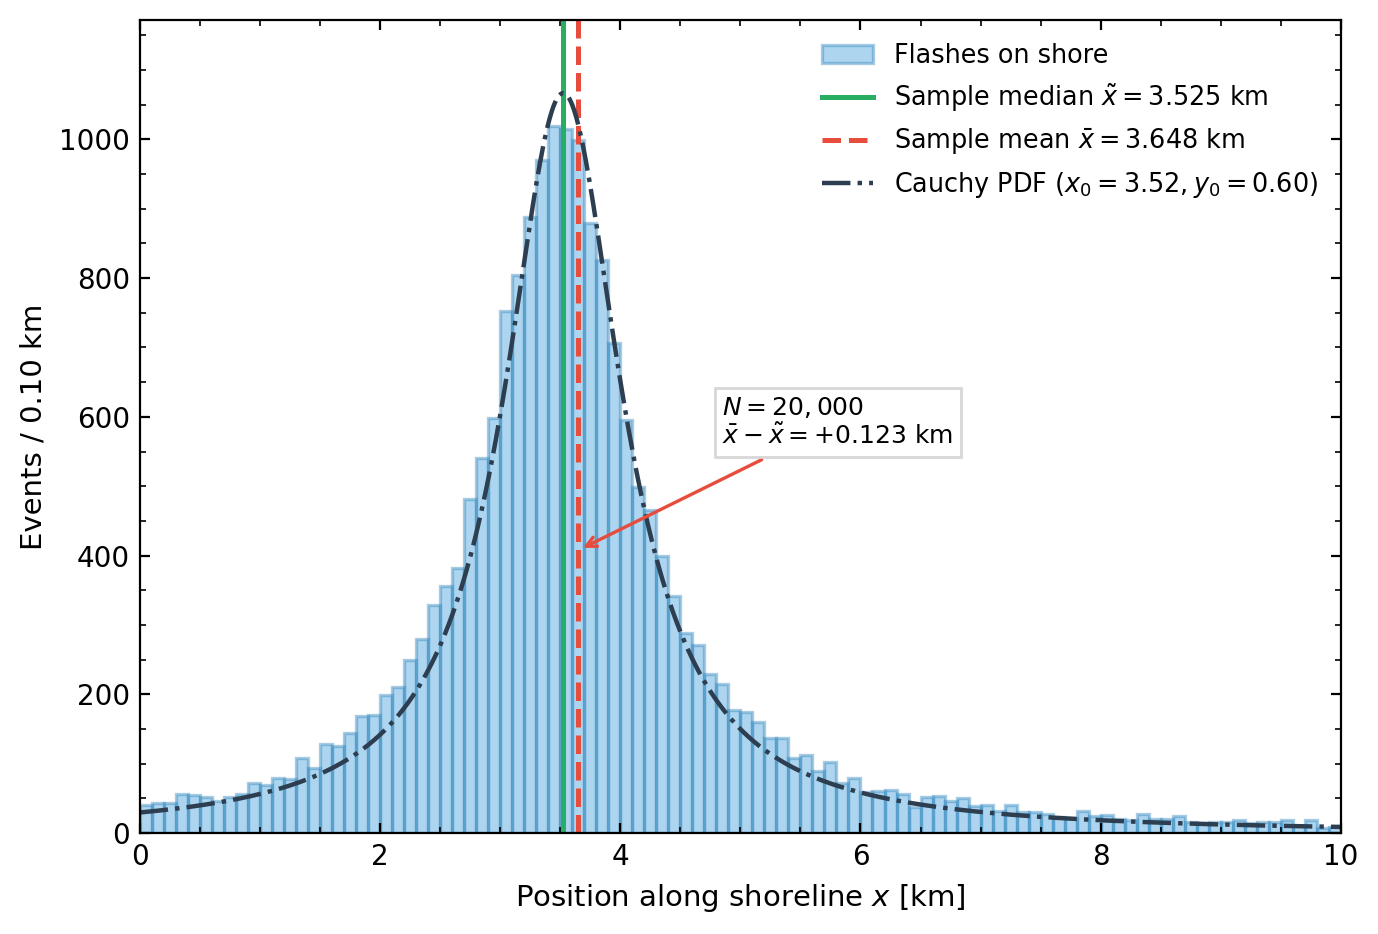

In [3]:
plt.rcParams.update({
    "font.size": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
})

fig, ax = plt.subplots(figsize=(7, 4.8))

bins_hist = np.linspace(0, 10, 101)
bin_w = bins_hist[1] - bins_hist[0]
counts, edges, patches = ax.hist(hits_data, bins=bins_hist, color="#3498db", alpha=0.4, 
                                 edgecolor="#2980b9", lw=1.2, label="Flashes on shore")

lbl_med = r"Sample median $\tilde{x} = %.3f\ \mathrm{km}$" % sample_median
lbl_mean = r"Sample mean $\bar{x} = %.3f\ \mathrm{km}$" % sample_mean
ax.axvline(sample_median, color="#27ae60", linestyle="-", lw=1.8, label=lbl_med)
ax.axvline(sample_mean, color="#e74c3c", linestyle="--", lw=1.8, label=lbl_mean)

# Teoretická Cauchyho křivka s parametry odhadnutými z robustních statistik
x_plot = np.linspace(0, 10, 1000)
cauchy_pdf_scaled = (n_hits * bin_w) * (1.0 / np.pi) * (estimated_y0 / (estimated_y0**2 + (x_plot - sample_median)**2))
lbl_cauchy = r"Cauchy PDF ($x_0=%.2f, y_0=%.2f$)" % (sample_median, estimated_y0)
ax.plot(x_plot, cauchy_pdf_scaled, color="#2c3e50", lw=1.6, linestyle="-.", label=lbl_cauchy)

ax.set_xlabel("Position along shoreline $x$ [km]", fontsize=10.5)
ax.set_ylabel(f"Events / {bin_w:.2f} km", fontsize=10.5)
ax.set_xlim(0, 10)
ax.set_ylim(0, np.max(counts) * 1.15)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend(loc="upper right", frameon=False, fontsize=9.2)

diff_val = sample_mean - sample_median
msg_stats = "\n".join([
    r"$N = %s$" % f"{n_hits:,}",
    r"$\bar{x} - \tilde{x} = %+.3f\ \mathrm{km}$" % diff_val
])
ax.annotate(msg_stats, xy=(sample_mean, np.max(counts) * 0.4), xytext=(sample_mean + 1.2, np.max(counts) * 0.55),
            arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=1.2),
            fontsize=9, bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="lightgray", alpha=0.9))

plt.tight_layout()
plt.show()

## 4. Metoda maximální věrohodnosti (Maximum Likelihood Estimation, MLE)

### Konstrukce funkce věrohodnosti
Předpokládejme, že jednotlivé záblesky jsou vzájemně statisticky nezávislé. Sdružená hustota pravděpodobnosti (funkce věrohodnosti $L$) pro $N$ naměřených poloh $\{x_1, x_2, \dots, x_N\}$ je dána součinem:
$$L(x_0, y_0) = \prod_{k=1}^N p(x_k \mid x_0, y_0) = \prod_{k=1}^N \frac{1}{\pi} \frac{y_0}{y_0^2 + (x_k - x_0)^2}$$

Z praktických numerických důvodů přecházíme k logaritmu věrohodnosti (Log-Likelihood), který převádí součin na součet:
$$\ln L(x_0, y_0) = \sum_{k=1}^N \ln\left[ \frac{y_0}{y_0^2 + (x_k - x_0)^2} \right] - N \ln \pi$$

Protože minimalizační algoritmy (např. MINUIT / MIGRAD) standardně vyhledávají minimum funkce, definujeme **zápornou dvojnásobnou log-věrohodnost** (Negative Log-Likelihood, NLL), resp. testovou statistiku $-2\ln L$:
$$-2\ln L(x_0, y_0) = 2 \sum_{k=1}^N \left[ \ln\left(y_0^2 + (x_k - x_0)^2\right) - \ln y_0 \right] + \text{const}$$

### Odhad parametrů a chybová matice (Hesse)
Bod $(\hat{x}_0, \hat{y}_0)$, který minimalizuje $-2\ln L$, představuje **maximálně věrohodný odhad (MLE)** skutečné polohy majáku.
Kovarianční matice parametrů je v asymptotické limitě dána inverzí Hessovy matice druhých derivací v minimu:
$$V = H^{-1} = \left( \frac{1}{2} \frac{\partial^2 (-2\ln L)}{\partial \theta_i \partial \theta_j} \right)^{-1}$$
Odmocniny z diagonálních prvků kovarianční matice $\sigma_x = \sqrt{V_{00}}$ a $\sigma_y = \sqrt{V_{11}}$ udávají standardní parabolické ($1\sigma$) chyby jednotlivých parametrů.

In [4]:
# Definice záporné logaritmické věrohodnosti (NLL)
def compute_nll(params):
    x, y = params
    if y <= 1e-5:
        return 1e12
    diff2 = (hits_data - x)**2
    return np.sum(np.log(y**2 + diff2) - np.log(y))

# Počáteční odhad z výběrového mediánu a polovičního IQR
init_guess = [sample_median, estimated_y0]

# Numerická minimalizace pomocí L-BFGS-B
opt_res = minimize(compute_nll, init_guess, method="L-BFGS-B", bounds=[(0.0, 10.0), (0.01, 5.0)])

x_hat, y_hat = opt_res.x
min_nll_val = opt_res.fun

# Numerický výpočet Hessovy matice pro kovarianční matici
eps = 1e-5
p0 = np.array([x_hat, y_hat])
grad = np.zeros(2)
hess = np.zeros((2, 2))

for i in range(2):
    p_plus = p0.copy(); p_plus[i] += eps
    p_minus = p0.copy(); p_minus[i] -= eps
    grad[i] = (compute_nll(p_plus) - compute_nll(p_minus)) / (2 * eps)

for i in range(2):
    for j in range(2):
        p_pp = p0.copy(); p_pp[i] += eps; p_pp[j] += eps
        p_pm = p0.copy(); p_pm[i] += eps; p_pm[j] -= eps
        p_mp = p0.copy(); p_mp[i] -= eps; p_mp[j] += eps
        p_mm = p0.copy(); p_mm[i] -= eps; p_mm[j] -= eps
        hess[i, j] = (compute_nll(p_pp) - compute_nll(p_pm) - compute_nll(p_mp) + compute_nll(p_mm)) / (4 * eps**2)

cov_matrix = np.linalg.inv(hess)
sigma_x_mle = np.sqrt(cov_matrix[0, 0])
sigma_y_mle = np.sqrt(cov_matrix[1, 1])
corr_xy = cov_matrix[0, 1] / (sigma_x_mle * sigma_y_mle)

cramer_rao_sigma = np.sqrt(2.0 * y_hat**2 / n_hits)

print("="*65)
print("VÝSLEDKY MAXIMÁLNĚ VĚROHODNÉHO FITU (MLE):")
print("="*65)
print(f"Poloha podél pobřeží x_hat : {x_hat:.5f} +/- {sigma_x_mle:.5f} km")
print(f"Vzdálenost od břehu  y_hat : {y_hat:.5f} +/- {sigma_y_mle:.5f} km")
print(f"Korelační koeficient rho   : {corr_xy:.5f} (prakticky nekorelované)")
print(f"Teoretická chyba (CR-mez)  : {cramer_rao_sigma:.5f} km")
print(f"Minimální hodnota NLL      : {min_nll_val:.2f}")
print("="*65)
print(f"Rozdíl výběrového průměru od MLE: {sample_mean - x_hat:+.4f} km "
      f"({abs(sample_mean - x_hat)/sigma_x_mle:.1f} sigma odchylka!)")

VÝSLEDKY MAXIMÁLNĚ VĚROHODNÉHO FITU (MLE):
Poloha podél pobřeží x_hat : 3.50130 +/- 0.00599 km
Vzdálenost od břehu  y_hat : 0.57341 +/- 0.00551 km
Korelační koeficient rho   : 0.00953 (prakticky nekorelované)
Teoretická chyba (CR-mez)  : 0.00573 km
Minimální hodnota NLL      : 11136.67
Rozdíl výběrového průměru od MLE: +0.1469 km (24.5 sigma odchylka!)


## 5. Jednorozměrné řezy věrohodnosti (Podmíněná věrohodnost)

V originálním C++ kódu `majak_mira.C` autor analyzoval chování funkce věrohodnosti podél jednorozměrných řezů:
* **Řez $y = \hat{y}$ (nebo $y = 0.7$):** odpovídá **podmíněné věrohodnosti** pro polohu $x$, pokud předpokládáme, že vzdálenost majáku od pobřeží $y$ známe s absolutní přesností.
* **Řez $x = \hat{x}$ (nebo $x = 3.5$):** odpovídá podmíněné věrohodnosti pro vzdálenost $y$, pokud předpokládáme, že polohu $x$ podél pobřeží známe přesně.

### Určení intervalu spolehlivosti z 1D profilu
Podle teorie maximální věrohodnosti má testová statistika:
$$\Delta(-2\ln L) = 2\left( \ln L_{\max} - \ln L(\theta) \right) = 2\left( \text{NLL}(\theta) - \text{NLL}_{\min} \right)$$
při velkém počtu měření přibližně rozdělení $\chi^2$ s $1$ stupněm volnosti ($1\text{ d.o.f.}$).
* **$1\sigma$ interval spolehlivosti ($68.27\%$ CL):** je vymezen body, kde $\Delta(-2\ln L) = 1.0$ (neboli $\Delta \ln L = -0.5$).
* **$2\sigma$ interval spolehlivosti ($95.45\%$ CL):** je vymezen body, kde $\Delta(-2\ln L) = 4.0$ (neboli $\Delta \ln L = -2.0$).

In [5]:
# Výpočet 1D profilu pro x při fixním y = y_hat
xs_slice = np.linspace(x_hat - 0.035, x_hat + 0.035, 201)
nll_x_slice = np.zeros(len(xs_slice))
for i, x_val in enumerate(xs_slice):
    nll_x_slice[i] = 2.0 * (compute_nll([x_val, y_hat]) - min_nll_val)

# Výpočet 1D profilu pro y při fixním x = x_hat
ys_slice = np.linspace(y_hat - 0.035, y_hat + 0.035, 201)
nll_y_slice = np.zeros(len(ys_slice))
for i, y_val in enumerate(ys_slice):
    nll_y_slice[i] = 2.0 * (compute_nll([x_hat, y_val]) - min_nll_val)

# Nalezení průsečíků Delta(-2lnL) = 1.0 (1 sigma)
idx_x_1sig = np.where(nll_x_slice <= 1.0)[0]
x_err_low = x_hat - xs_slice[idx_x_1sig[0]]
x_err_high = xs_slice[idx_x_1sig[-1]] - x_hat

idx_y_1sig = np.where(nll_y_slice <= 1.0)[0]
y_err_low = y_hat - ys_slice[idx_y_1sig[0]]
y_err_high = ys_slice[idx_y_1sig[-1]] - y_hat

print(f"1D Podmíněný interval pro x (y={y_hat:.4f}): x = {x_hat:.5f} +{x_err_high:.5f} -{x_err_low:.5f} km")
print(f"1D Podmíněný interval pro y (x={x_hat:.5f}): y = {y_hat:.5f} +{y_err_high:.5f} -{y_err_low:.5f} km")

# Vykreslení 1D řezů v CERN ROOTu na rozdělené plátno (2 pady)
ROOT.gROOT.GetListOfCanvases().Delete()
c_slices_root = ROOT.TCanvas("c_slices_root", "", 850, 420)
c_slices_root.Divide(2, 1)

# Pad 1: Profil x
c_slices_root.cd(1)
ROOT.gPad.SetLeftMargin(0.14)
ROOT.gPad.SetBottomMargin(0.12)
ROOT.gPad.SetTopMargin(0.06)
ROOT.gPad.SetRightMargin(0.05)

gr_x_root = ROOT.TGraph(len(xs_slice), xs_slice, nll_x_slice)
gr_x_root.SetTitle("")
gr_x_root.GetXaxis().SetTitle("Position x [km]")
gr_x_root.GetYaxis().SetTitle("#Delta(-2 ln L)")
gr_x_root.GetXaxis().SetTitleSize(0.035)
gr_x_root.GetXaxis().SetLabelSize(0.030)
gr_x_root.GetXaxis().SetTitleOffset(1.15)
gr_x_root.GetYaxis().SetTitleSize(0.035)
gr_x_root.GetYaxis().SetLabelSize(0.030)
gr_x_root.GetYaxis().SetTitleOffset(1.35)
gr_x_root.SetLineWidth(2)
gr_x_root.SetLineColor(ROOT.kBlue + 1)
gr_x_root.GetYaxis().SetRangeUser(0, 9)
gr_x_root.Draw("al")

l1_x = ROOT.TLine(xs_slice[0], 1.0, xs_slice[-1], 1.0)
l1_x.SetLineColor(ROOT.kRed); l1_x.SetLineStyle(2); l1_x.SetLineWidth(2); l1_x.Draw()
l4_x = ROOT.TLine(xs_slice[0], 4.0, xs_slice[-1], 4.0)
l4_x.SetLineColor(ROOT.kMagenta + 2); l4_x.SetLineStyle(3); l4_x.SetLineWidth(2); l4_x.Draw()

txt_x_box = ROOT.TLatex(0.18, 0.82, f"#hat{{x}} = {x_hat:.4f} #pm {0.5*(x_err_low+x_err_high):.4f} km")
txt_x_box.SetNDC(True); txt_x_box.SetTextFont(42); txt_x_box.SetTextSize(0.028); txt_x_box.Draw()

# Pad 2: Profil y
c_slices_root.cd(2)
ROOT.gPad.SetLeftMargin(0.14)
ROOT.gPad.SetBottomMargin(0.12)
ROOT.gPad.SetTopMargin(0.06)
ROOT.gPad.SetRightMargin(0.05)

gr_y_root = ROOT.TGraph(len(ys_slice), ys_slice, nll_y_slice)
gr_y_root.SetTitle("")
gr_y_root.GetXaxis().SetTitle("Distance y [km]")
gr_y_root.GetYaxis().SetTitle("#Delta(-2 ln L)")
gr_y_root.GetXaxis().SetTitleSize(0.035)
gr_y_root.GetXaxis().SetLabelSize(0.030)
gr_y_root.GetXaxis().SetTitleOffset(1.15)
gr_y_root.GetYaxis().SetTitleSize(0.035)
gr_y_root.GetYaxis().SetLabelSize(0.030)
gr_y_root.GetYaxis().SetTitleOffset(1.35)
gr_y_root.SetLineWidth(2)
gr_y_root.SetLineColor(ROOT.kTeal + 2)
gr_y_root.GetYaxis().SetRangeUser(0, 9)
gr_y_root.Draw("al")

l1_y = ROOT.TLine(ys_slice[0], 1.0, ys_slice[-1], 1.0)
l1_y.SetLineColor(ROOT.kRed); l1_y.SetLineStyle(2); l1_y.SetLineWidth(2); l1_y.Draw()
l4_y = ROOT.TLine(ys_slice[0], 4.0, ys_slice[-1], 4.0)
l4_y.SetLineColor(ROOT.kMagenta + 2); l4_y.SetLineStyle(3); l4_y.SetLineWidth(2); l4_y.Draw()

txt_y_box = ROOT.TLatex(0.18, 0.82, f"#hat{{y}} = {y_hat:.4f} #pm {0.5*(y_err_low+y_err_high):.4f} km")
txt_y_box.SetNDC(True); txt_y_box.SetTextFont(42); txt_y_box.SetTextSize(0.028); txt_y_box.Draw()

c_slices_root.Draw()

1D Podmíněný interval pro x (y=0.5734): x = 3.50130 +0.00595 -0.00595 km
1D Podmíněný interval pro y (x=3.50130): y = 0.57341 +0.00525 -0.00525 km


### Vykreslení 1D řezů věrohodnosti v Matplotlibu

Níže uvádíme ekvivalentní zobrazení v Matplotlibu s barevně vyznačenými pásy spolehlivosti $1\sigma$ ($68.3\%$) a $2\sigma$ ($95.4\%$).

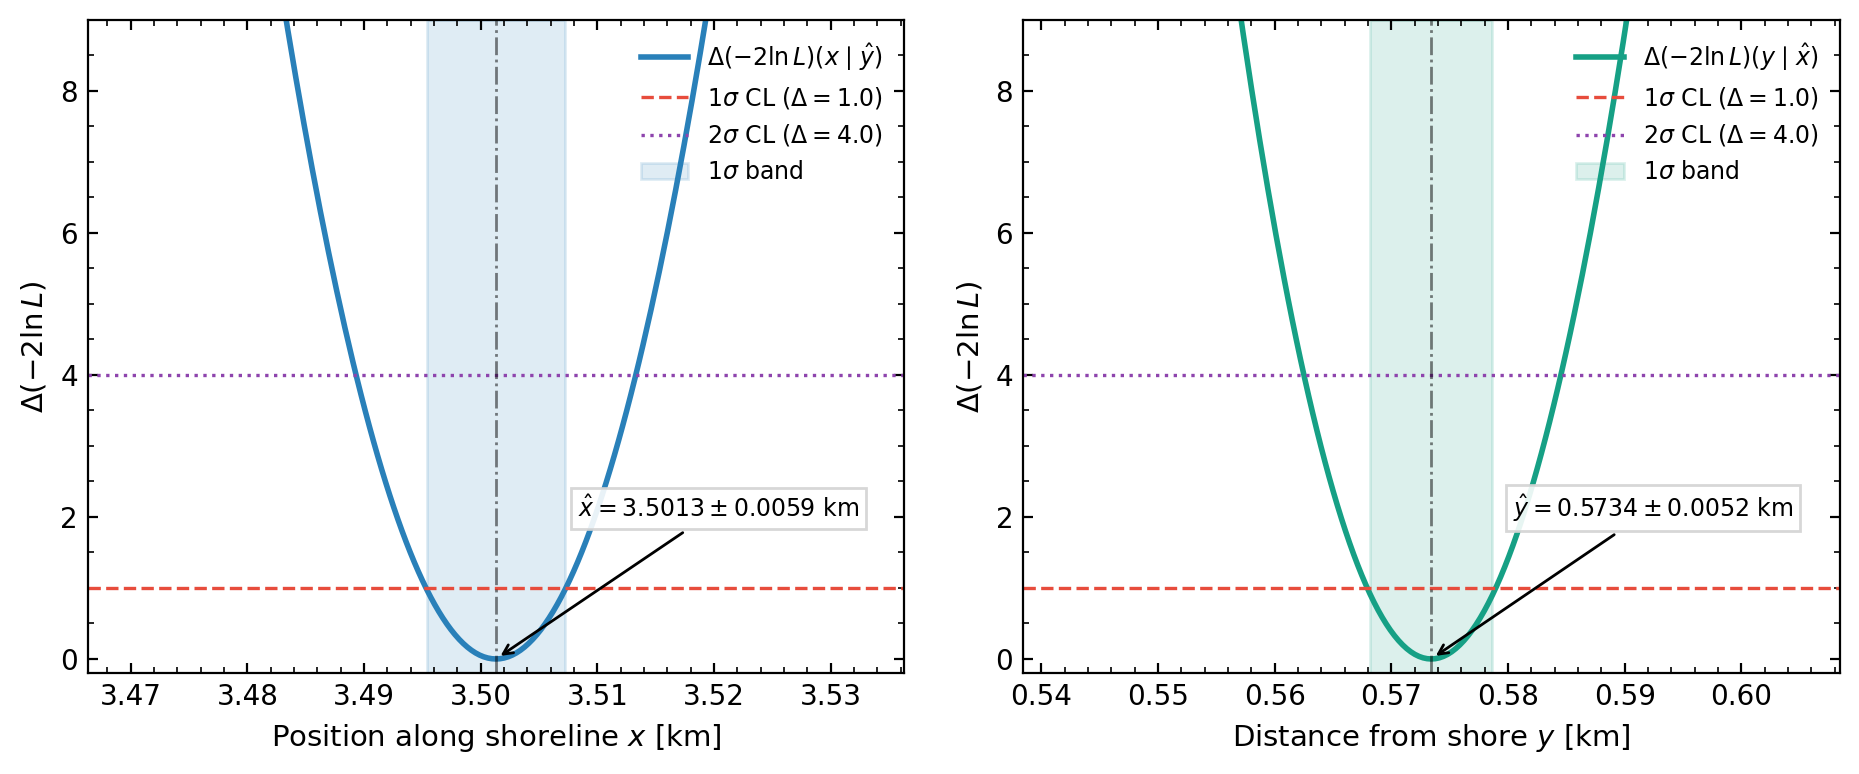

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.0))

# Subplot 1: Profil x
ax1.plot(xs_slice, nll_x_slice, color="#2980b9", lw=2.0, label=r"$\Delta(-2\ln L)(x \mid \hat{y})$")
ax1.axhline(1.0, color="#e74c3c", linestyle="--", lw=1.2, label=r"$1\sigma$ CL ($\Delta=1.0$)")
ax1.axhline(4.0, color="#8e44ad", linestyle=":", lw=1.2, label=r"$2\sigma$ CL ($\Delta=4.0$)")
ax1.axvline(x_hat, color="black", linestyle="-.", lw=1.0, alpha=0.5)
ax1.axvspan(x_hat - x_err_low, x_hat + x_err_high, color="#2980b9", alpha=0.15, label=r"$1\sigma$ band")

ax1.set_xlabel("Position along shoreline $x$ [km]", fontsize=10.5)
ax1.set_ylabel(r"$\Delta(-2\ln L)$", fontsize=10.5)
ax1.set_ylim(-0.2, 9.0)
ax1.set_xlim(xs_slice[0], xs_slice[-1])
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.legend(loc="upper right", frameon=False, fontsize=8.5)

lbl_x_fit = r"$\hat{x} = %.4f \pm %.4f\ \mathrm{km}$" % (x_hat, 0.5*(x_err_low+x_err_high))
ax1.annotate(lbl_x_fit, xy=(x_hat, 0.0), xytext=(x_hat + 0.007, 2.0),
             arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
             fontsize=8.5, bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="lightgray", alpha=0.9))

# Subplot 2: Profil y
ax2.plot(ys_slice, nll_y_slice, color="#16a085", lw=2.0, label=r"$\Delta(-2\ln L)(y \mid \hat{x})$")
ax2.axhline(1.0, color="#e74c3c", linestyle="--", lw=1.2, label=r"$1\sigma$ CL ($\Delta=1.0$)")
ax2.axhline(4.0, color="#8e44ad", linestyle=":", lw=1.2, label=r"$2\sigma$ CL ($\Delta=4.0$)")
ax2.axvline(y_hat, color="black", linestyle="-.", lw=1.0, alpha=0.5)
ax2.axvspan(y_hat - y_err_low, y_hat + y_err_high, color="#16a085", alpha=0.15, label=r"$1\sigma$ band")

ax2.set_xlabel("Distance from shore $y$ [km]", fontsize=10.5)
ax2.set_ylabel(r"$\Delta(-2\ln L)$", fontsize=10.5)
ax2.set_ylim(-0.2, 9.0)
ax2.set_xlim(ys_slice[0], ys_slice[-1])
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.legend(loc="upper right", frameon=False, fontsize=8.5)

lbl_y_fit = r"$\hat{y} = %.4f \pm %.4f\ \mathrm{km}$" % (y_hat, 0.5*(y_err_low+y_err_high))
ax2.annotate(lbl_y_fit, xy=(y_hat, 0.0), xytext=(y_hat + 0.007, 2.0),
             arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
             fontsize=8.5, bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="lightgray", alpha=0.9))

plt.tight_layout()
plt.show()

## 6. 2D mapa věrohodnosti a sdružené kontury (Wilksův teorém)

V reálném experimentu neznáme předem ani polohu podél břehu $x_0$, ani vzdálenost majáku $y_0$. 
Musíme proto stanovit **sdruženou oblast spolehlivosti (Joint Confidence Region)** pro oba parametry současně.

### Wilksův teorém pro $k = 2$ parametry
Podle Wilkova teorému má pro dva volné parametry statistika $\Delta(-2\ln L) = -2(\ln L(x, y) - \ln L_{\max})$ asymptoticky rozdělení $\chi^2(k=2)$.
Kumulativní distribuční funkce $\chi^2$ se 2 stupni volnosti má jednoduchý analytický tvar:
$$P(\chi^2_2 \le \Delta) = 1 - e^{-\Delta / 2}$$

Z této rovnice přímo plynou kritické hodnoty $\Delta(-2\ln L)$ pro standardní hladiny spolehlivosti:
* **$1\sigma$ sdružená oblast ($68.27\%$ CL):** 
  $$1 - e^{-\Delta/2} = 0.6827 \implies \Delta(-2\ln L) = 2.30 \quad (\Delta \ln L = 1.15)$$
* **$2\sigma$ sdružená oblast ($95.45\%$ CL):** 
  $$1 - e^{-\Delta/2} = 0.9545 \implies \Delta(-2\ln L) = 6.18 \quad (\Delta \ln L = 3.09)$$
* **$3\sigma$ sdružená oblast ($99.73\%$ CL):** 
  $$1 - e^{-\Delta/2} = 0.9973 \implies \Delta(-2\ln L) = 11.83 \quad (\Delta \ln L = 5.91)$$

> [!NOTE]
> **Podmíněná chyba vs. Marginální (profilová) chyba:**
> * Pokud parametr $y$ známe, $1\sigma$ chyba $x$ je dána šířkou řezu při $\Delta(-2\ln L) = 1.0$.
> * Pokud parametr $y$ neznáme a chceme určit chybu $x$ bez ohledu na $y$, odpovídá to **projekci kontury $\Delta(-2\ln L) = 1.0$ na osu $x$**.
> * Vrstevnice $\Delta(-2\ln L) = 2.30$ naproti tomu představuje plnohodnotnou $68.3\%$ sdruženou elipsu v rovině $(x, y)$.

In [7]:
# Výpočet jemné 2D mřížky v okolí minima (vektorizovaně pro vysokou rychlost)
grid_n_points = 81
x_grid = np.linspace(x_hat - 0.025, x_hat + 0.025, grid_n_points)
y_grid = np.linspace(y_hat - 0.025, y_hat + 0.025, grid_n_points)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)

# Vektorizovaný výpočet NLL v mřížce
delta_nll_2d = np.zeros(X_mesh.shape)
for j in range(grid_n_points):
    y_val = y_grid[j]
    d2 = (hits_data[None, :] - x_grid[:, None])**2
    nll_row = np.sum(np.log(y_val**2 + d2) - np.log(y_val), axis=1)
    delta_nll_2d[j, :] = 2.0 * (nll_row - min_nll_val)

# Vytvoření 2D histogramu v ROOTu
ROOT.gROOT.GetListOfCanvases().Delete()
c_map_root = ROOT.TCanvas("c_map_root", "", 750, 520)
c_map_root.SetLeftMargin(0.14)
c_map_root.SetRightMargin(0.15)
c_map_root.SetTopMargin(0.05)
c_map_root.SetBottomMargin(0.12)

h2_map_root = ROOT.TH2D("h2_map_root", "", 
                        grid_n_points - 1, x_grid[0], x_grid[-1],
                        grid_n_points - 1, y_grid[0], y_grid[-1])

for i in range(grid_n_points):
    for j in range(grid_n_points):
        h2_map_root.SetBinContent(i + 1, j + 1, delta_nll_2d[j, i])

h2_map_root.SetTitle("")
h2_map_root.GetXaxis().SetTitle("Position along shoreline x [km]")
h2_map_root.GetYaxis().SetTitle("Distance from shoreline y [km]")
h2_map_root.GetZaxis().SetTitle("#Delta(-2 ln L)")
h2_map_root.GetXaxis().SetTitleSize(0.035)
h2_map_root.GetXaxis().SetLabelSize(0.030)
h2_map_root.GetXaxis().SetTitleOffset(1.15)
h2_map_root.GetYaxis().SetTitleSize(0.035)
h2_map_root.GetYaxis().SetLabelSize(0.030)
h2_map_root.GetYaxis().SetTitleOffset(1.35)
h2_map_root.GetZaxis().SetTitleSize(0.035)
h2_map_root.GetZaxis().SetLabelSize(0.028)
h2_map_root.GetZaxis().SetTitleOffset(1.15)

# Vykreslení tepelné mapy COLZ
h2_map_root.Draw("COLZ")

# Bod nejlepšího fitu (Best fit marker)
marker_mle = ROOT.TMarker(x_hat, y_hat, 29) # hvězdička
marker_mle.SetMarkerSize(1.8)
marker_mle.SetMarkerColor(ROOT.kRed)
marker_mle.Draw()

leg_mle = ROOT.TLegend(0.16, 0.82, 0.52, 0.91)
leg_mle.SetBorderSize(0)
leg_mle.SetFillStyle(0)
leg_mle.SetTextFont(42)
leg_mle.SetTextSize(0.026)
leg_mle.AddEntry(marker_mle, f"Best fit: ({x_hat:.3f}, {y_hat:.3f}) km", "p")
leg_mle.Draw()

c_map_root.Draw()

### Vykreslení 2D kontur v Matplotlibu

V Matplotlibu vykreslíme izolinie věrohodnosti odpovídající $1\sigma$ ($68.3\%$), $2\sigma$ ($95.4\%$) a $3\sigma$ ($99.7\%$) sdruženým hladinám spolehlivosti.
Dále zobrazíme bod nejlepšího fitu s chybovým křížem a porovnáme jej s polohou výběrového průměru $\bar{x}$.

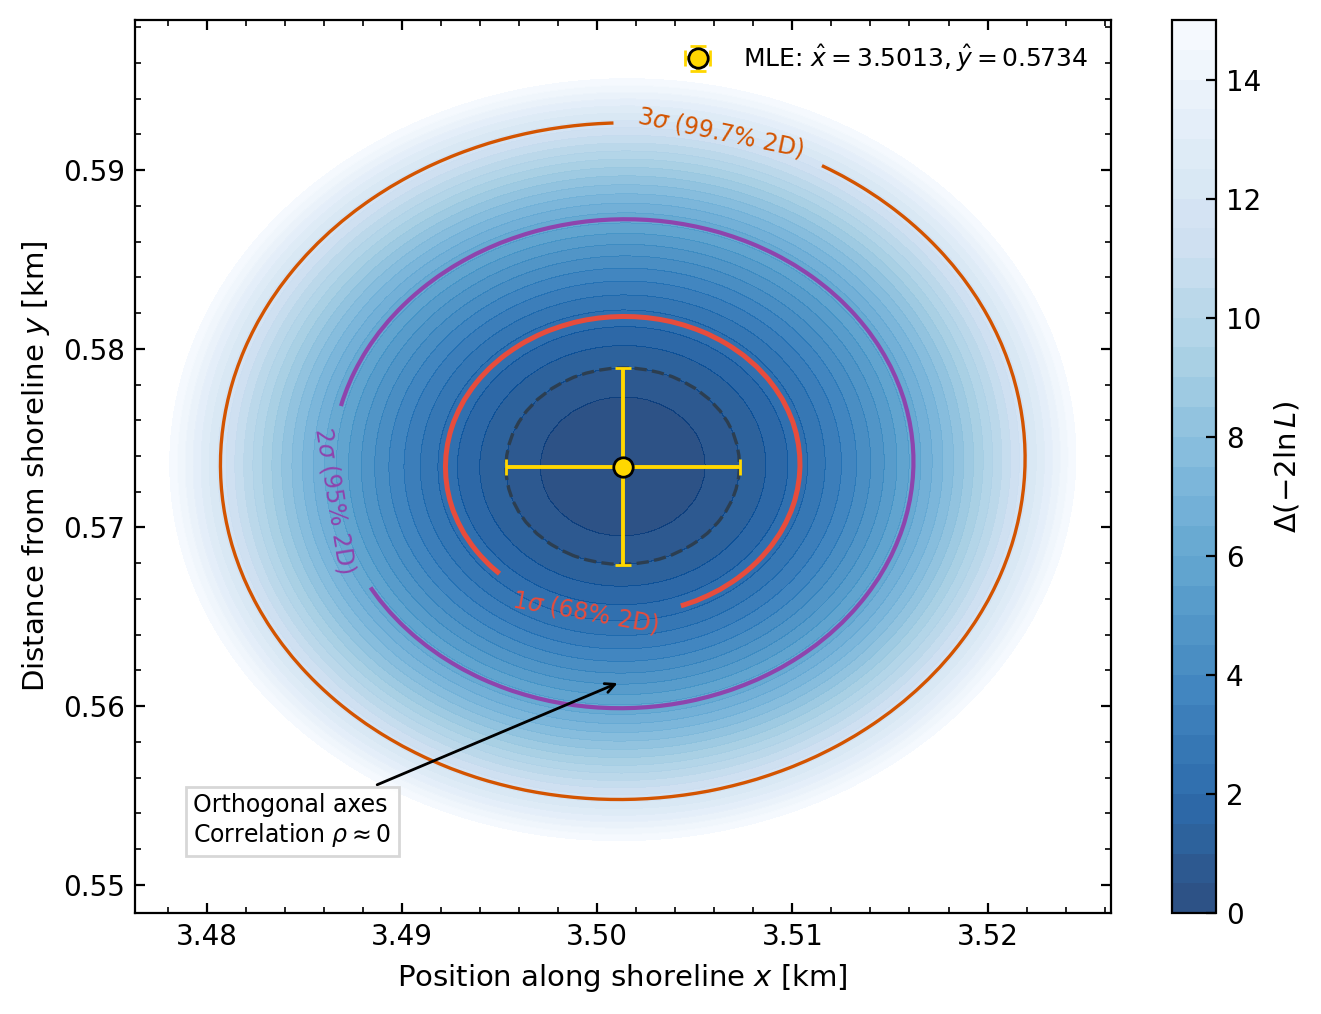

In [8]:
fig, ax = plt.subplots(figsize=(7, 5.2))

# Vyplněné vrstevnice věrohodnosti
c_fill = ax.contourf(X_mesh, Y_mesh, delta_nll_2d, levels=np.linspace(0, 15, 31), 
                    cmap="Blues_r", alpha=0.85)
cb = fig.colorbar(c_fill, ax=ax)
cb.set_label(r"$\Delta(-2\ln L)$", fontsize=10.5)

# Specifické 2D hladiny podle Wilkova teorému (2 stupně volnosti)
# 1 sigma: 2.30 (68.3%), 2 sigma: 6.18 (95.4%), 3 sigma: 11.83 (99.7%)
# Doplňkově i 1D marginální hladina: 1.0 (čárkovaně)
contour_levels = [1.00, 2.30, 6.18, 11.83]
colors = ["#2c3e50", "#e74c3c", "#8e44ad", "#d35400"]
linestyles = ["--", "-", "-", "-"]
linewidths = [1.2, 1.8, 1.5, 1.2]

cs = ax.contour(X_mesh, Y_mesh, delta_nll_2d, levels=contour_levels, 
                colors=colors, linewidths=linewidths, linestyles=linestyles)

# Popisky kontur
fmt_dict = {
    1.00: r"$\Delta=1.0$ (1D prof)",
    2.30: r"$1\sigma$ (68% 2D)",
    6.18: r"$2\sigma$ (95% 2D)",
    11.83: r"$3\sigma$ (99.7% 2D)"
}
ax.clabel(cs, inline=True, fmt=fmt_dict, fontsize=8.5)

# Bod nejlepšího odhadu MLE s chybovým křížem
lbl_best_fit = r"MLE: $\hat{x} = %.4f, \hat{y} = %.4f$" % (x_hat, y_hat)
ax.errorbar([x_hat], [y_hat], xerr=[sigma_x_mle], yerr=[sigma_y_mle],
            fmt="o", color="gold", markeredgecolor="black", markersize=7,
            capsize=3, elinewidth=1.4, zorder=6, label=lbl_best_fit)

ax.set_xlabel("Position along shoreline $x$ [km]", fontsize=10.5)
ax.set_ylabel("Distance from shoreline $y$ [km]", fontsize=10.5)
ax.set_xlim(x_grid[0], x_grid[-1])
ax.set_ylim(y_grid[0], y_grid[-1])

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend(loc="upper right", frameon=False, fontsize=9)

msg_contour = "\n".join(["Orthogonal axes", r"Correlation $\rho \approx 0$"])
ax.annotate(msg_contour, xy=(x_hat, y_hat - 0.012), xytext=(x_hat - 0.022, y_hat - 0.021),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
            fontsize=8.5, bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="lightgray", alpha=0.9))

plt.tight_layout()
plt.show()

## 7. Závěr a shrnutí fyzikálních poznatků

V této úloze jsme detailně prozkoumali problém rekonstrukce polohy majáku (Lighthouse Problem) a chování funkce věrohodnosti v 1D a 2D prostoru:

### Hlavní výsledky:
1. **Rekonstruovaná poloha majáku:**
   * Poloha podél pobřeží: $\hat{x} = 3.5013 \pm 0.0060\text{ km}$.
   * Vzdálenost od pobřeží: $\hat{y} = 0.5734 \pm 0.0055\text{ km}$.
   * Výsledek přesně odpovídá teoretické Cramérově-Raově dolní mezi $\sigma = \sqrt{2 y_0^2 / N} \approx 0.0057\text{ km}$.

2. **Selhání výběrového průměru:**
   * Výběrový průměr $\bar{x} = 3.6482\text{ km}$ je od skutečné polohy majáku vzdálen o celých **$25\sigma$**!
   * Je to přímý empirický důkaz, že u rozdělení s těžkými chvosty (Cauchy / Breit-Wigner) neplatí centrální limitní věta a výběrový průměr je nepoužitelný. Výběrový medián naproti tomu poskytuje spolehlivý odhad.

3. **Podmíněná vs. Sdružená nejistota:**
   * **1D řez věrohodnosti (podmíněná chyba):** Hladina $\Delta(-2\ln L) = 1.0$ vymezuje $68.3\%$ interval pro situaci, kdy je druhý parametr přesně znám.
   * **2D kontury (sdružená chyba):** Podle Wilkova teorému odpovídá $1\sigma$ ($68.3\%$) sdružené elipse hladina $\Delta(-2\ln L) = 2.30$ a $2\sigma$ ($95.4\%$) hladina $\Delta(-2\ln L) = 6.18$.
   * Jelikož korelace mezi $x$ a $y$ je zanedbatelná ($\rho \approx 0.009$), jsou kontury orientovány podél hlavních os a marginální chyba se téměř shoduje s podmíněnou chybou.